## Voice

In [20]:
import IPython
from scipy.io import wavfile
from scipy.io.wavfile import write

import matplotlib.pyplot as plt
import numpy as np

In [21]:
rate, s = wavfile.read('output.wav')

Smapling Rate  44100
Duration Seconds 4.18


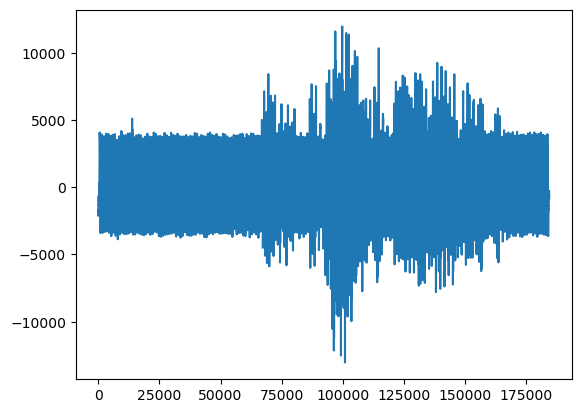

In [38]:
plt.plot(s[:, 0])
duration_seconds = len(s) / rate
print(f"Smapling Rate ", rate)
print(f"Duration Seconds {duration_seconds:.2f}")

IPython.display.Audio(s[:, 0], rate=rate)


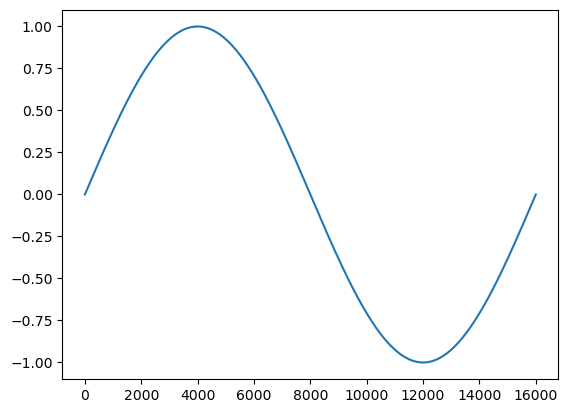

In [40]:
t = np.linspace(0., 1., 16000)

y = np.sin(2.0*np.pi*t)
plt.plot(y);

> Integer PCM (Pulse Code Modulation): 16-bit PCM audio uses 16-bit signed integers

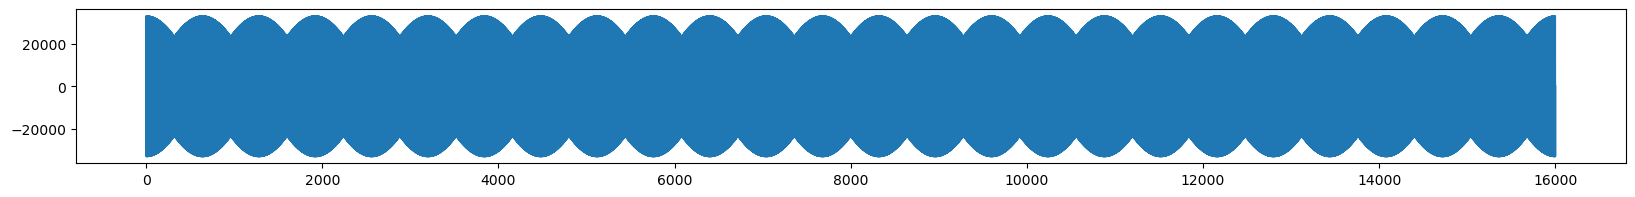

In [44]:
samplerate = 16000; fs = 100000

t = np.linspace(0., 1., samplerate)

amplitude = np.iinfo(np.int16).max

data = amplitude * np.sin(2. * np.pi * fs * t)

fig = plt.figure(figsize=(20, 2))
plt.plot(data)
IPython.display.Audio(data, rate=16000)

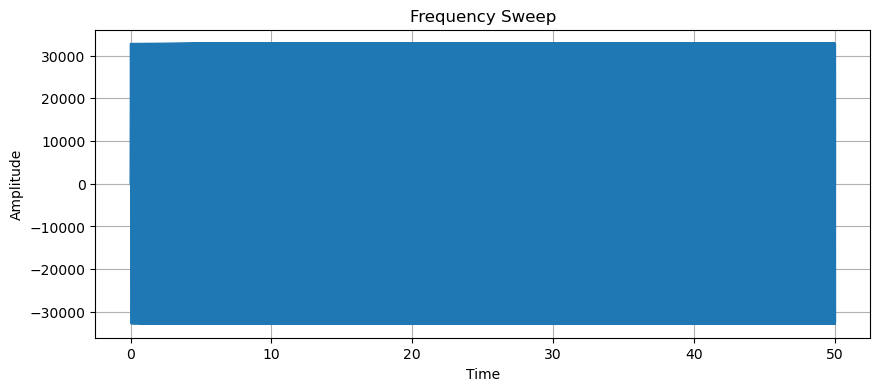

In [58]:
import IPython.display


samplerate = 16000
duration = 50


t = np.linspace(0., duration, int(samplerate * duration), endpoint=False)


start_freq = 10
end_freq = 1_000_000


data = np.sin(2. * np.pi * np.logspace(np.log10(start_freq), np.log10(end_freq), len(t)) * t)


amp = np.iinfo(np.int16).max
data = amp * data / np.max(np.abs(data))


fig = plt.figure(figsize=(10, 4))
plt.plot(t, data)
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Frequency Sweep')
plt.grid(True)

IPython.display.Audio(data, rate=samplerate)

## Add Signals

In [75]:
samplerate = 16000; fs1 = 20000; fs2 = 500

t = np.linspace(0., 1., samplerate)

amplitude = np.iinfo(np.int16).max

data1 = amplitude * np.sin(2. * np.pi * fs1 * t)
data2 = amplitude * np.sin(2. * np.pi * fs2 * t)


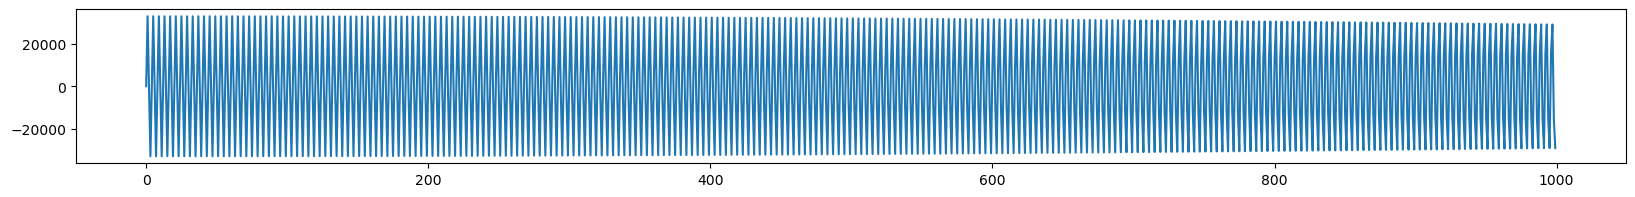

In [78]:
fig = plt.figure(figsize=(20, 2))
plt.plot(data1[:1000])
IPython.display.Audio(data1, rate=16000)

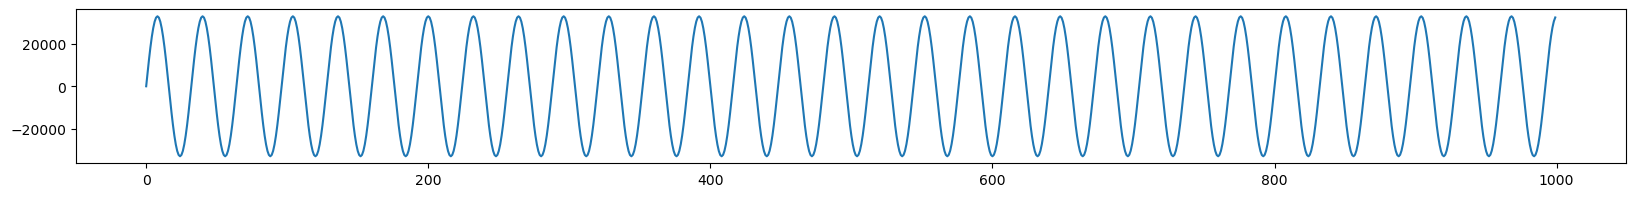

In [77]:
fig = plt.figure(figsize=(20, 2))
plt.plot(data2[:1000])
IPython.display.Audio(data2, rate=16000)

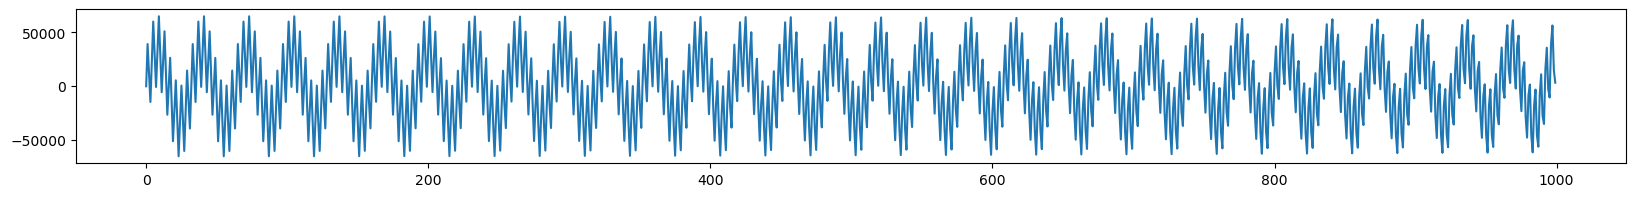

In [79]:
data = data1 + data2
fig = plt.figure(figsize=(20, 2))
plt.plot(data[:1000])
IPython.display.Audio(data, rate=16000)

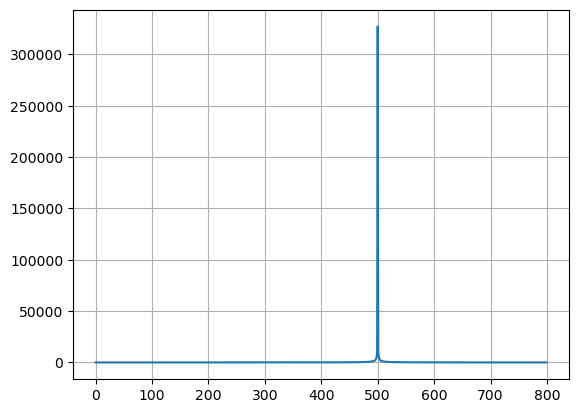

In [80]:
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt


N = 1600

T = 1/1600

yf = fft(data)

xf = fftfreq(N, T)[:N//2]


plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))


plt.grid()

plt.show()

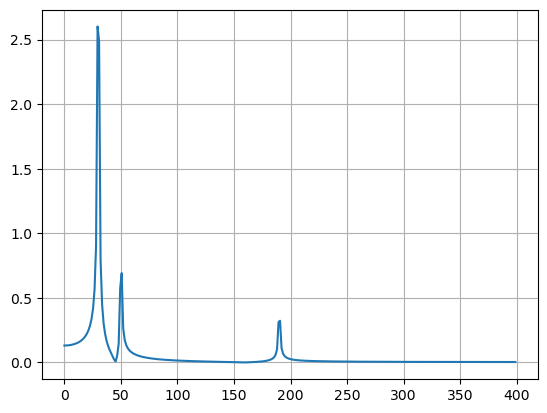

In [81]:
N = 600


T = 1.0 / 800.0

x = np.linspace(0.0, N*T, N, endpoint=False)

y = np.sin(50.0 * 2.0*np.pi*x) + 0.5*np.sin(190.0 * 2.0*np.pi*x)+ 4 *np.sin(30.0 * 2.0*np.pi*x)

yf = fft(y)

xf = fftfreq(N, T)[:N//2]


plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))

plt.grid()

plt.show()

## Spectogram

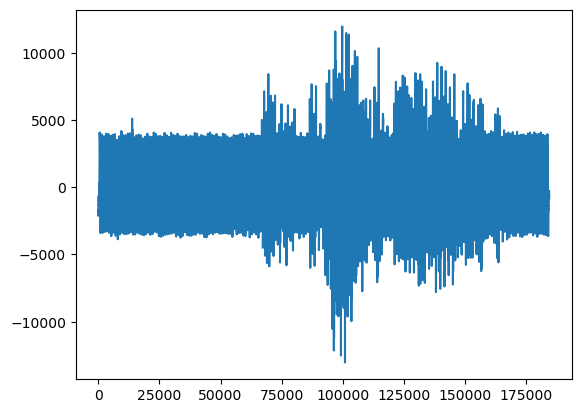

In [3]:
import IPython
from scipy.io import wavfile
from scipy.io.wavfile import write

import matplotlib.pyplot as plt
import numpy as np

rate, s = wavfile.read('output.wav')
plt.plot(s[:, 0])
IPython.display.Audio(s[..., 0], rate=rate)

In [4]:
import tensorflow as tf
s = s[..., 0].astype(float) / 32767.0

spectrogram = tf.signal.stft(
    s, frame_length=225, frame_step=128
)
spectrogram = tf.abs(spectrogram)
spectrogram.shape

2025-03-20 19:21:53.002950: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


TensorShape([1439, 129])

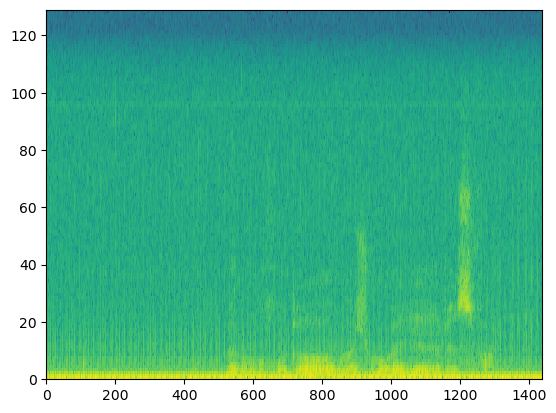

In [6]:
log_spec = np.log(spectrogram.numpy().T)
plt.pcolormesh(log_spec);